<a href="https://colab.research.google.com/github/suavejavi/Data201-labs/blob/main/Copy_of_Weeks_4_and_5_labs_Classification_and_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Learning Objectives
By the end of this lab, you should be able to:
1. Fit an LDA classification model.
2. Fit a QDA classification model.
3. Fit a K-Nearest Neighbors classification model.
4. Explain why one classifier may be more appropriate than another.
5. Use cross-validation to compare models and select tuning parameters.
6. Evaluate a classification model using:
   - K-fold cross-validation
   - classification thresholds
   - confusion matrix
   - accuracy
   - precision
   - recall/sensitivity
   - specificity
   - F1 score
   - ROC curve
   - AUC

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Part 1- LDA vs. QDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Smarket = pd.read_csv("/content/drive/MyDrive/Data 201/Datasets/Smarket.csv")
Smarket.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


The S&P 500 (Standard & Poor's 500) is a stock market index that tracks the performance of 500 of the largest publicly traded companies in the United States. It's widely considered one of the best indicators of overall U.S. stock market performance and is often used as a benchmark for investment portfolios. This dataset contains weekly percentage returns for the S&P 500 from 1990 to 2010.

**Dataset Documentation:** https://intro-stat-learning.github.io/ISLP/datasets/Weekly.html

For real-time S&P 500 information and broader U.S. market data, visit: https://www.cnbc.com/markets/us-markets/

In [ ]:
Smarket.shape

(1250, 9)

In [ ]:
Smarket.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


In [ ]:
Smarket["Direction"].value_counts()

,count
Direction,
Up,648
Down,602


Summary statistics by Direction:
               Lag1                          Lag2                    
               mean       std      skew      mean       std      skew
Direction                                                            
Down       0.050686  1.141070  0.102351  0.032297  1.157174 -0.144657
Up        -0.039691  1.130989  0.292008 -0.022444  1.116768  0.550644
               Lag1      Lag2
Direction                    
Down       1.141070  1.157174
Up         1.130989  1.116768


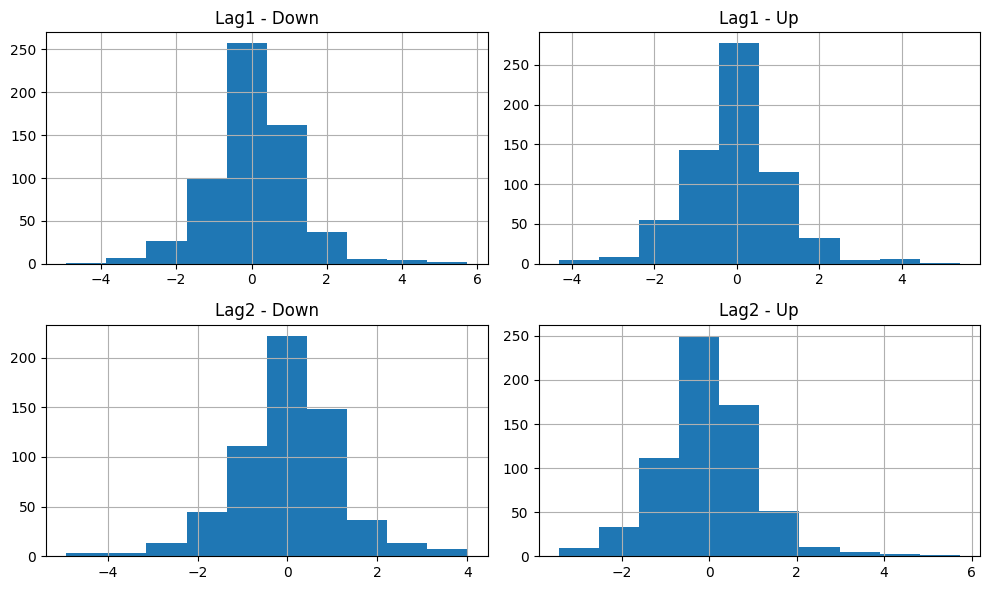

In [ ]:
# Check normality visually and compare covariance structures

# 1. Summary statistics by class
print("Summary statistics by Direction:")
print(
    Smarket.groupby("Direction")[["Lag1", "Lag2"]].agg(
        ["mean", "std", "skew"]
    )
)

# 2. standard deviation for each class
print(Smarket.groupby("Direction")[["Lag1", "Lag2"]].std())

# 3. Histograms by class
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

Smarket[Smarket["Direction"] == "Down"]["Lag1"].hist(ax=axes[0,0])
axes[0,0].set_title("Lag1 - Down")

Smarket[Smarket["Direction"] == "Up"]["Lag1"].hist(ax=axes[0,1])
axes[0,1].set_title("Lag1 - Up")

Smarket[Smarket["Direction"] == "Down"]["Lag2"].hist(ax=axes[1,0])
axes[1,0].set_title("Lag2 - Down")

Smarket[Smarket["Direction"] == "Up"]["Lag2"].hist(ax=axes[1,1])
axes[1,1].set_title("Lag2 - Up")

plt.tight_layout()
plt.show()

- Lag1 and Lag2 look roughly bell-shaped within each class.
- Standard deviations for the Up and Down groups have roughly similar spread and relationships.
- The covariance matrices for the Up and Down classes are very similar, so the equal-covariance assumption of LDA appears reasonable. Because QDA allows separate covariance matrices, its extra flexibility may not be necessary for this dataset.

Using:
- Lag1: Percentage return for previous week

- Lag2: Percentage return for 2 weeks previous

As predictors, predict the Direction (A factor with levels ‘Down’ and ‘Up’ indicating whether the market had a positive or negative return on a given week.)

In [ ]:
# set your features and target
X = Smarket[["Lag1", "Lag2"]]

y = Smarket["Direction"]

#The Smarket data contain observations from several years. We will use:
#years before 2005 → training data
#2005 → test data

train = Smarket["Year"] < 2005

X_train = X[train]
X_test = X[~train]

y_train = y[train]
y_test = y[~train]

In [ ]:
X_train.shape, X_test.shape

((998, 2), (252, 2))

#### Part 1A- LDA

In [ ]:
#LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#Create model
lda = LinearDiscriminantAnalysis()

#Fit the model
lda.fit(X_train, y_train)

#Make prediction
lda_pred = lda.predict(X_test)

Remember, for binary classification, the matrix represents:

|                |   Predicted No |  Predicted Yes |
| -------------- | -------------: | -------------: |
| **Actual No**  |  True Negative | False Positive |
| **Actual Yes** | False Negative |  True Positive |

Positive here = Up


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

print(accuracy_score(y_test, lda_pred))
print(confusion_matrix(y_test, lda_pred,  labels=["Down", "Up"]))

0.5595238095238095
[[ 35  76]
 [ 35 106]]


#### Cross-Validation with LDA
- A single train/test split gives us only one estimate of model performance.
- Cross-validation allows us to evaluate the model repeatedly using different subsets of the training data.

We will use 5-fold cross-validation.

In [ ]:
from sklearn.model_selection import cross_val_score

lda_cv = cross_val_score(
    lda,
    X_train,
    y_train,
    cv=5
)

lda_cv

array([0.445     , 0.505     , 0.495     , 0.54773869, 0.52261307])

In [ ]:
print(lda_cv.mean())

0.503070351758794


What Cross-Validation Does (5-Fold Example)

X_train is divided into 5 equal parts             

Fold 1: Use 80% for training, 20% for validation   
Fold 2: Rotate, use different 80%/20% split        
Fold 3: Rotate again                             
Fold 4: Rotate again                             
Fold 5: Final rotation                          

Result: 5 different accuracy scores, then we take the mean of them           

Note: Cross-validation is mainly for getting a more reliable estimate of how the model performs on unseen data. It does not automatically improve the model itself.

In our case:
- Test accuracy on 2005 data: 55.95%
- Mean 5-fold CV accuracy on the training data: 50.31%

That is completely possible because the two numbers come from different validation sets. The 2005 test set may simply be easier for LDA than the average validation fold inside the training data.


Also, for LDA there is no tuning happening here. We are just evaluating the same LDA model 5 times. So CV is not making LDA “better.”

For KNN, cross-validation can indirectly help you build a better final model because you use CV to choose the best K. But even then, the final test accuracy is not guaranteed to be higher than the CV accuracy.

#### Graphing LDA Classification

In [ ]:
import numpy as np
# Create a grid that covers the Lag1 and Lag2 values
x_min, x_max = X_train["Lag1"].min() - 1, X_train["Lag1"].max() + 1
y_min, y_max = X_train["Lag2"].min() - 1, X_train["Lag2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Put the grid points into a DataFrame
grid = pd.DataFrame({
    "Lag1": xx.ravel(),
    "Lag2": yy.ravel()
})

# Ask LDA to classify every point in the grid
grid_pred = lda.predict(grid)

# Convert Down/Up to 0/1 for plotting
grid_pred_num = np.where(grid_pred == "Up", 1, 0)

grid_pred_num = grid_pred_num.reshape(xx.shape)

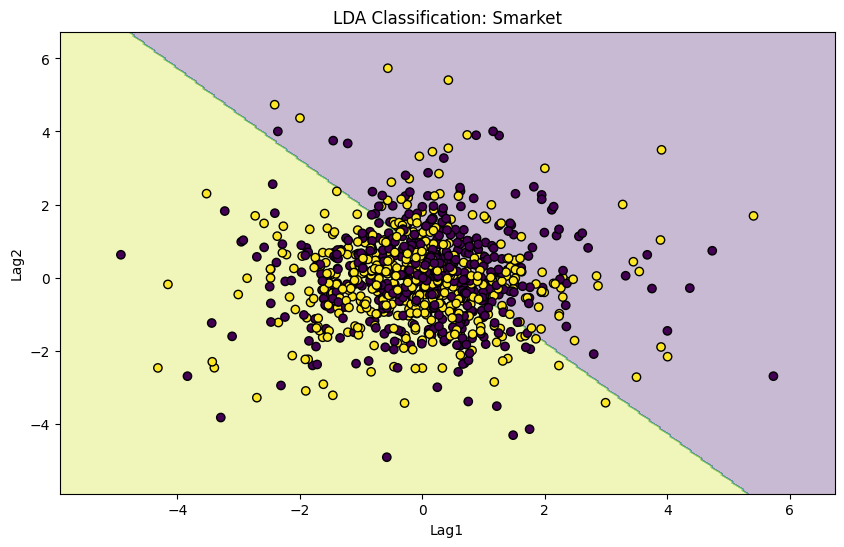

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.contourf(
    xx,
    yy,
    grid_pred_num,
    alpha=0.3
)

plt.scatter(
    X_train["Lag1"],
    X_train["Lag2"],
    c=np.where(y_train == "Up", 1, 0),
    edgecolor="k"
)

plt.xlabel("Lag1")
plt.ylabel("Lag2")
plt.title("LDA Classification: Smarket")

plt.show()

LDA produces a straight-line decision boundary between the two predicted regions.

For Smarket, the classes overlap heavily, which helps explain why the accuracy is only around 50–56%.

### Part 1B — QDA

In [ ]:
#QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

#Create model
qda = QuadraticDiscriminantAnalysis()

#Fit the model
qda.fit(X_train, y_train)

#Make prediction
qda_pred = qda.predict(X_test)

In [ ]:
print(accuracy_score(y_test, qda_pred))
print(confusion_matrix(y_test, qda_pred,  labels=["Down", "Up"]))

0.5992063492063492
[[ 30  81]
 [ 20 121]]


#### Cross-Validation with QDA

In [ ]:
qda_cv = cross_val_score(
    qda,
    X_train,
    y_train,
    cv=5
)

print(qda_cv)
print(qda_cv.mean())

[0.44       0.395      0.5        0.56281407 0.49748744]
0.47906030150753764


- QDA achieved a higher test accuracy than LDA, about **59.9% compared with 56.0%**, so QDA performed better on the 2005 test data.
- However, QDA mean 5-fold cross-validation accuracy was lower, about **47.9% compared with 50.3% for LDA**. This means QDA did better on this particular test set, but LDA performed slightly better on average across the cross-validation folds.

- The QDA confusion matrix also shows that it predicted “Up” very often, correctly identifying many Up days but also incorrectly classifying many Down days as Up.

In [ ]:
# Create a grid that covers the Lag1 and Lag2 values
x_min, x_max = X_train["Lag1"].min() - 1, X_train["Lag1"].max() + 1
y_min, y_max = X_train["Lag2"].min() - 1, X_train["Lag2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Put the grid points into a DataFrame
grid = pd.DataFrame({
    "Lag1": xx.ravel(),
    "Lag2": yy.ravel()
})

# Have QDA classify every point in the grid
grid_pred = qda.predict(grid)

# Convert Down and Up to numbers for plotting
grid_pred_num = np.where(
    grid_pred == "Up",
    1,
    0
)

grid_pred_num = grid_pred_num.reshape(xx.shape)

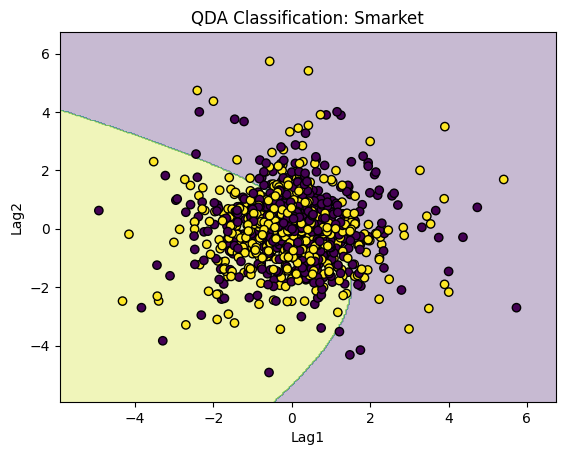

In [ ]:
plt.contourf(
    xx,
    yy,
    grid_pred_num,
    alpha=0.3
)

plt.scatter(
    X_train["Lag1"],
    X_train["Lag2"],
    c=np.where(y_train == "Up", 1, 0),
    edgecolor="k"
)

plt.xlabel("Lag1")
plt.ylabel("Lag2")
plt.title("QDA Classification: Smarket")

plt.show()

#### 1C - KNN
I will create a dataset using make_moons function. It create a simple toy dataset to visualize clustering and classification algorithms. Read more https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

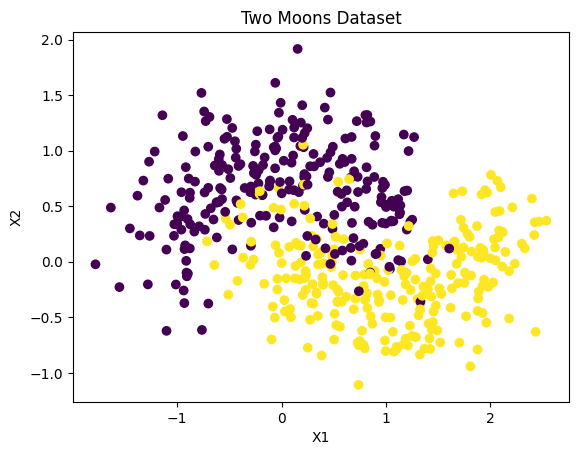

In [ ]:
#create a dataset
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=500,
    noise=0.30,
    random_state=1
)

#Graph it
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Two Moons Dataset")

plt.show()

KNN does not estimate a straight-line equation. Instead, when a new observation must be classified, KNN looks at nearby training observations and asks:

- What class do most of my neighbors belong to?

This allows KNN to create very flexible decision boundaries.

A large dataset with only a few predictors and a curved boundary is a reasonable setting for KNN.  Classification-LDA QDA KNN

In [ ]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

#To classify:
#Start by splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

#scale
knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

#fit the model
knn.fit(X_train, y_train)

#predict test data
knn_pred = knn.predict(X_test)

#evaluate
accuracy_score(y_test, knn_pred)


0.92

### But Why Did We Choose K = 5?
We shouldn't simply guess. We can use cross-validation to select K.

In [ ]:
#Test these possible values
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

#create an empty list
cv_scores = []

#Run cross-validation
for k in k_values:

    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5
    )

    cv_scores.append(scores.mean())

print(cv_scores)

[np.float64(0.8826666666666666), np.float64(0.8799999999999999), np.float64(0.9039999999999999), np.float64(0.8959999999999999), np.float64(0.9066666666666666), np.float64(0.8959999999999999), np.float64(0.8933333333333333), np.float64(0.8933333333333332)]


Best choice is k = 9 because it has the highest mean cross-validation accuracy, about 90.67%.

#### Plot K vs. Cross-Validation Accuracy

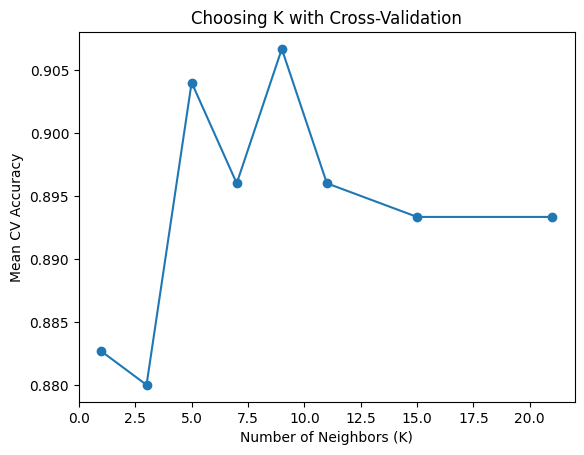

In [ ]:
plt.plot(
    k_values,
    cv_scores,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")
plt.title("Choosing K with Cross-Validation")

plt.show()

### Fit the Final KNN Mode (k=9)

In [ ]:
best_knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=9)
)

#fit
best_knn.fit(X_train, y_train)

#predict
best_knn_pred = best_knn.predict(X_test)

#evaluate
accuracy_score(y_test, best_knn_pred)

0.92

#### Graph KNN, k =9

In [ ]:
# Create a grid covering the predictor space
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Combine all grid points
grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

# Ask KNN to classify every point
grid_pred = best_knn.predict(grid)

# Reshape predictions to match the grid
grid_pred = grid_pred.reshape(xx.shape)

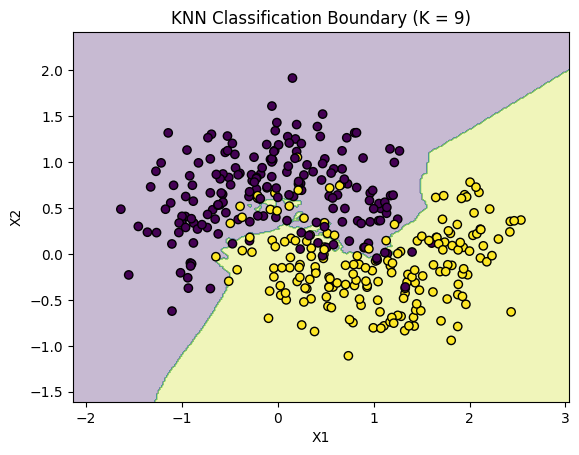

In [ ]:
plt.contourf(
    xx,
    yy,
    grid_pred,
    alpha=0.3
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("KNN Classification Boundary (K = 9)")

plt.show()

KNN can follow the irregular, nonlinear shape of the data rather than being restricted to a straight line like LDA or a quadratic boundary like QDA

## Part 2 — Complete Model Evaluation

For this section, we will use LDA on the Default dataset.

The response is highly imbalanced: in the class material, only 333 of 10,000 customers default, meaning an "always No" classifier achieves about 96.7% accuracy. That makes it obvious why accuracy alone is not enough.

##### Workflow:
Full data → train/test split → K-fold CV on training data → fit final model on all training data → use test data once → probabilities → threshold → confusion matrix → metrics → ROC/AUC.

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Data 201/Datasets/Default.csv"

Default = pd.read_csv(file_path)

Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
Default["default"].value_counts()

,count
default,
No,9667
Yes,333


### Goal:
We will use: balance and income to predict default

In [ ]:
#set the variables
X = Default[["balance", "income"]]

y = Default["default"]

#First split the full data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

#Create LDA Model
lda = LinearDiscriminantAnalysis()

#Do not fit it to all the training data yet
#Perform 5-fold cross-validation on the training data

#Create k-fold
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

#Run K-fold cross-validation only on the training set.
cv_scores = cross_val_score(
    lda,
    X_train,
    y_train,
    cv=kfold,
)

#view results


print(cv_scores)
print(cv_scores.mean())



[0.96733333 0.97266667 0.974      0.97133333 0.97333333]
0.9717333333333332


We are not using Cross-validation to compare for LDA vs. QDA as we did in Part 1. We are also not using CV to choose a parameter like k in KNN.

Cross-validation, here, gives us a more reliable estimate of expected model performance than looking at one split alone. once we are satisfied with the model, we want the final version to learn from as much training data as possible.

In [ ]:
#Fit the final model using all training data
lda.fit(X_train, y_train)

#Get predicted probabilities on the unseen test set
lda.classes_

#get the probability of defaulting "Yes"
prob_yes = lda.predict_proba(X_test)[:, 1]

prob_yes[:10]

array([0.00195553, 0.00501936, 0.00184266, 0.01381051, 0.06403314,
       0.00011086, 0.00014972, 0.00043611, 0.00469401, 0.00020966])

In [ ]:
import numpy as np

#Threshold = 50%
pred_50 = np.where(
    prob_yes >= 0.50,
    "Yes",
    "No"
)

#Confusion Matrix
cm = confusion_matrix(
    y_test,
    pred_50,
    labels=["No", "Yes"]
)

print(cm)

TN, FP, FN, TP = cm.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

[[2411    6]
 [  58   25]]
TN: 2411
FP: 6
FN: 58
TP: 25


In [ ]:
#Metrics

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
accuracy = accuracy_score(
    y_test,
    pred_50
)

precision = precision_score(
    y_test,
    pred_50,
    pos_label="Yes"
)

recall = recall_score(
    y_test,
    pred_50,
    pos_label="Yes"
)

specificity = TN / (TN + FP)

f1 = f1_score(
    y_test,
    pred_50,
    pos_label="Yes"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1:", f1)

Accuracy: 0.9744
Precision: 0.8064516129032258
Recall: 0.30120481927710846
Specificity: 0.9975175837815474
F1: 0.43859649122807015


In [ ]:
#change threshold to 20%
pred_20 = np.where(
    prob_yes >= 0.20,
    "Yes",
    "No"
)

#CM
cm20 = confusion_matrix(
    y_test,
    pred_20,
    labels=["No", "Yes"]
)

print(cm20)

#metrics
TN20, FP20, FN20, TP20 = cm20.ravel()

accuracy20 = accuracy_score(
    y_test,
    pred_20
)

precision20 = precision_score(
    y_test,
    pred_20,
    pos_label="Yes"
)

recall20 = recall_score(
    y_test,
    pred_20,
    pos_label="Yes"
)

specificity20 = TN20 / (TN20 + FP20)

f1_20 = f1_score(
    y_test,
    pred_20,
    pos_label="Yes"
)

print("Accuracy:", accuracy20)
print("Precision:", precision20)
print("Recall:", recall20)
print("Specificity:", specificity20)
print("F1:", f1_20)

[[2355   62]
 [  34   49]]
Accuracy: 0.9616
Precision: 0.44144144144144143
Recall: 0.5903614457831325
Specificity: 0.9743483657426562
F1: 0.5051546391752577


These results show exactly why threshold choice matters.

- At a **0.50 threshold**, the model has very high accuracy (**97.44%**) and specificity (**99.75%**), but recall is only **30.12%**, meaning it misses most of the customers who actually default.

- When the threshold is lowered to **0.20**, recall rises substantially to **59.04%**, so the model identifies many more true defaulters, but precision drops from **80.65% to 44.14%** and accuracy decreases slightly to **96.16%** because more non-defaulters are incorrectly flagged.

-The F1 score improves from **0.439 to 0.505**, showing that the lower threshold gives a better balance between precision and recall.

#### ROC curve

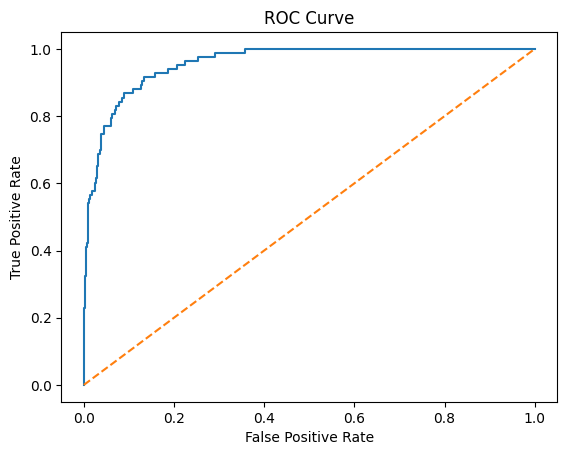

In [ ]:
import matplotlib.pyplot as plt

#convert the response to 0/1
y_test_binary = np.where(
    y_test == "Yes",
    1,
    0
)

#calculate the curve
fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    prob_yes
)

#plot
plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [ ]:
#AUC
auc = roc_auc_score(
    y_test_binary,
    prob_yes
)

print("AUC:", auc)

AUC: 0.9577839699717363


An AUC of 0.958 means the LDA model does a very good job separating customers who default from those who do not across all possible classification threshold.

The threshold changes the confusion matrix and metrics like recall and precision, but the ROC-AUC summarizes the model’s discrimination across all thresholds rather than depending on just 0.50 or 0.20.